# Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score,accuracy_score, f1_score, classification_report)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Load All CSV Files

In [2]:
transaction = pd.read_excel("Transaction.xlsx")
user        = pd.read_excel("User.xlsx")
city        = pd.read_excel("City.xlsx")
country     = pd.read_excel("Country.xlsx")
region      = pd.read_excel("Region.xlsx")
continent   = pd.read_excel("Continent.xlsx")
item        = pd.read_excel("Updated_Item.xlsx")   
visit_mode  = pd.read_excel("Mode.xlsx")
attr_type   = pd.read_excel("Type.xlsx")


In [3]:
print("Raw shapes:")
for name, df in [("Transaction", transaction), ("User", user), ("City", city),
                 ("Country", country), ("Region", region), ("Continent", continent),
                 ("Item", item), ("VisitMode", visit_mode), ("AttrType", attr_type)]:
    print(f"  {name:12s}: {df.shape}   columns: {list(df.columns)}")

Raw shapes:
  Transaction : (52930, 7)   columns: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating']
  User        : (33530, 5)   columns: ['UserId', 'ContinentId', 'RegionId', 'CountryId', 'CityId']
  City        : (9143, 3)   columns: ['CityId', 'CityName', 'CountryId']
  Country     : (165, 3)   columns: ['CountryId', 'Country', 'RegionId']
  Region      : (22, 3)   columns: ['Region', 'RegionId', 'ContinentId']
  Continent   : (6, 2)   columns: ['ContinentId', 'Continent']
  Item        : (1698, 5)   columns: ['AttractionId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']
  VisitMode   : (6, 2)   columns: ['VisitModeId', 'VisitMode']
  AttrType    : (17, 2)   columns: ['AttractionTypeId', 'AttractionType']


# Understand the data

In [4]:
print("=" * 60)
print("TRANSACTION (first 5 rows):")
display(transaction.head())
print("\nUSER (first 5 rows):")
display(user.head())
print("\nITEM / ATTRACTIONS (first 5 rows):")
display(item.head())
print("\nVISIT MODE:")
display(visit_mode)
print("\nATTRACTION TYPES:")
display(attr_type)
print("\nCONTINENT:")
display(continent)
print("\nREGION:")
display(region.head())

TRANSACTION (first 5 rows):


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3



USER (first 5 rows):


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0



ITEM / ATTRACTIONS (first 5 rows):


...

,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets
5,44,Historic Sites
6,45,History Museums
7,61,National Parks
8,63,Nature & Wildlife Areas
9,64,Neighborhoods



CONTINENT:


,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania
5,5,Europe



REGION:


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


# Clean Transaction Table 

In [5]:
transaction.drop_duplicates(inplace=True)
transaction.dropna(subset=["UserId", "AttractionId", "Rating", "VisitMode"], inplace=True)

transaction["UserId"]       = transaction["UserId"].astype(int)
transaction["AttractionId"] = transaction["AttractionId"].astype(int)
transaction["VisitYear"]    = transaction["VisitYear"].astype(int)
transaction["VisitMonth"]   = transaction["VisitMonth"].astype(int)
transaction["VisitMode"]    = transaction["VisitMode"].astype(int)
transaction["Rating"]       = transaction["Rating"].astype(float)

# Keep only valid ratings 1–5
transaction = transaction[transaction["Rating"].between(1, 5)]

# Remove VisitMode = 0 (placeholder "unknown")
transaction = transaction[transaction["VisitMode"] != 0]

print(f"Transaction shape after cleaning: {transaction.shape}")
print("\nNull counts:")
print(transaction.isnull().sum())
print("\nRating value counts:")
print(transaction["Rating"].value_counts().sort_index())
print("\nVisitMode value counts:")
print(transaction["VisitMode"].value_counts())

Transaction shape after cleaning: (52930, 7)

Null counts:
TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64

Rating value counts:
1.0     1263
2.0     2035
3.0     7730
4.0    17966
5.0    23936
Name: Rating, dtype: int64

VisitMode value counts:
2    21620
3    15217
4    10945
5     4525
1      623
Name: VisitMode, dtype: int64


# Clean User Table

In [6]:
# CELL 6 — Clean User table
user.drop_duplicates(subset=["UserId"], inplace=True)
user.dropna(subset=["UserId"], inplace=True)

# Convert IDs to int (fill missing geography with 0 = unknown)
for col in ["ContinentId", "RegionId", "CountryId", "CityId"]:
    user[col] = user[col].fillna(0).astype(int)

user["UserId"] = user["UserId"].astype(int)

print(f"User shape after cleaning: {user.shape}")
print(user.isnull().sum())

User shape after cleaning: (33530, 5)
UserId         0
ContinentId    0
RegionId       0
CountryId      0
CityId         0
dtype: int64


# Clean all Reference Table 

### City

In [7]:
city["CityId"]    = city["CityId"].fillna(0).astype(int)
city["CountryId"] = city["CountryId"].fillna(0).astype(int)
city["CityName"]  = city["CityName"].str.strip()
city = city[city["CityId"] != 0]   # remove placeholder row

### Country

In [8]:
country = country[country["CountryId"] != 0]
country["Country"] = country["Country"].str.strip()
country["CountryId"] = country["CountryId"].astype(int)
country["RegionId"]  = country["RegionId"].astype(int)

### Region

In [9]:
region = region[region["RegionId"] != 0]
region.rename(columns={"Region": "RegionName"}, inplace=True)
region["RegionId"]    = region["RegionId"].astype(int)
region["ContinentId"] = region["ContinentId"].astype(int)

### Continent

In [10]:
continent = continent[continent["ContinentId"] != 0]
continent["ContinentId"] = continent["ContinentId"].astype(int)

### Item(Attraction)

In [11]:
item.drop_duplicates(subset=["AttractionId"], inplace=True)
item.dropna(subset=["AttractionId", "AttractionCityId"], inplace=True)
item["AttractionId"]     = item["AttractionId"].astype(int)
item["AttractionCityId"] = item["AttractionCityId"].astype(int)
item["Attraction"]       = item["Attraction"].str.strip()

### AttractionTypeId has mixed int/string values — handle carefully

In [12]:
item["AttractionTypeId"] = pd.to_numeric(item["AttractionTypeId"], errors="coerce").fillna(0).astype(int)

### Visit Mode

In [13]:
visit_mode.columns = ["VisitMode", "VisitModeName"]  # rename for merge
visit_mode = visit_mode[visit_mode["VisitMode"] != 0]


### Attraction Type

In [14]:
attr_type["AttractionTypeId"] = attr_type["AttractionTypeId"].astype(int)

In [15]:
print("All reference tables cleaned!")
for name, df in [("City", city), ("Country", country), ("Region", region),
                 ("Continent", continent), ("Item", item)]:
    print(f"  {name}: {df.shape}")

All reference tables cleaned!
  City: (9142, 3)
  Country: (164, 3)
  Region: (21, 3)
  Continent: (5, 2)
  Item: (1698, 5)


# Build Master(Merged) Dataset 

In [16]:
df = transaction.copy()

# Join user demographics
df = df.merge(user, on="UserId", how="left")

# Join geography names
df = df.merge(city[["CityId", "CityName"]], on="CityId", how="left")
df = df.merge(country[["CountryId", "Country"]], on="CountryId", how="left")
df = df.merge(region[["RegionId", "RegionName"]], on="RegionId", how="left")
df = df.merge(continent[["ContinentId", "Continent"]], on="ContinentId", how="left")

# Join attraction details
df = df.merge(
    item[["AttractionId", "AttractionTypeId", "Attraction", "AttractionCityId"]],
    on="AttractionId", how="left"
)

# Join attraction type label
df = df.merge(attr_type, on="AttractionTypeId", how="left")

# Join visit mode label
df = df.merge(visit_mode, on="VisitMode", how="left")

# Fill missing name columns
for col in ["CityName", "Country", "RegionName", "Continent",
            "Attraction", "AttractionType", "VisitModeName"]:
    df[col] = df[col].fillna("Unknown")

print(f"Master dataset shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
display(df.head(3))

Master dataset shape: (52930, 20)

Columns:
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'CityName', 'Country', 'RegionName', 'Continent', 'AttractionTypeId', 'Attraction', 'AttractionCityId', 'AttractionType', 'VisitModeName']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,CityName,Country,RegionName,Continent,AttractionTypeId,Attraction,AttractionCityId,AttractionType,VisitModeName
0,3,70456,2022,10,2,640,5.0,5,21,163,4341,Guildford,United Kingdom,Western Europe,Europe,63,Sacred Monkey Forest Sanctuary,1,Nature & Wildlife Areas,Couples
1,8,7567,2022,10,4,640,5.0,2,8,48,464,Ontario,Canada,Northern America,America,63,Sacred Monkey Forest Sanctuary,1,Nature & Wildlife Areas,Friends
2,9,79069,2022,10,3,640,5.0,2,9,54,774,Brazil,Brazil,South America,America,63,Sacred Monkey Forest Sanctuary,1,Nature & Wildlife Areas,Family


# Feature Engineering

### 1. Season from visit month

In [17]:
def get_season(month):
    if month in [12, 1, 2]:   return "Winter"
    elif month in [3, 4, 5]:  return "Spring"
    elif month in [6, 7, 8]:  return "Summer"
    else:                      return "Autumn"

df["Season"] = df["VisitMonth"].apply(get_season)

### 2. Average rating per attraction

In [18]:
avg_attr_rating = df.groupby("AttractionId")["Rating"].mean().rename("AvgAttractionRating")
df = df.merge(avg_attr_rating, on="AttractionId", how="left")

### 3. Average rating per user

In [19]:
avg_user_rating = df.groupby("UserId")["Rating"].mean().rename("AvgUserRating")
df = df.merge(avg_user_rating, on="UserId", how="left")

### 4. Total visit count per user

In [20]:
user_visit_count = df.groupby("UserId")["TransactionId"].count().rename("UserVisitCount")
df = df.merge(user_visit_count, on="UserId", how="left")

In [21]:
print(f"Shape after feature engineering: {df.shape}")
print("\nNew features added: Season, AvgAttractionRating, AvgUserRating, UserVisitCount")
print(f"\nSeason distribution:\n{df['Season'].value_counts()}")
display(df[["VisitMonth", "Season", "AvgAttractionRating", "AvgUserRating", "UserVisitCount"]].head())

Shape after feature engineering: (52930, 24)

New features added: Season, AvgAttractionRating, AvgUserRating, UserVisitCount

Season distribution:
Summer    14248
Autumn    13478
Winter    12671
Spring    12533
Name: Season, dtype: int64


,VisitMonth,Season,AvgAttractionRating,AvgUserRating,UserVisitCount
0,10,Autumn,4.267086,5.0,1
1,10,Autumn,4.267086,5.0,1
2,10,Autumn,4.267086,5.0,1
3,10,Autumn,4.267086,3.0,2
4,10,Autumn,4.267086,3.0,3


# EDA (Exploratory Data Analysis)

In [22]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Transactions : {len(df):,}")
print(f"Unique Users       : {df['UserId'].nunique():,}")
print(f"Unique Attractions : {df['AttractionId'].nunique():,}")
print(f"Year Range         : {df['VisitYear'].min()} – {df['VisitYear'].max()}")
print(f"Average Rating     : {df['Rating'].mean():.2f}")
print(f"\nRating Distribution:\n{df['Rating'].value_counts().sort_index()}")
print(f"\nVisit Mode Distribution:\n{df['VisitModeName'].value_counts()}")
print(f"\nContinent Distribution:\n{df['Continent'].value_counts()}")

DATASET OVERVIEW
Total Transactions : 52,930
Unique Users       : 33,530
Unique Attractions : 30
Year Range         : 2013 – 2022
Average Rating     : 4.16

Rating Distribution:
1.0     1263
2.0     2035
3.0     7730
4.0    17966
5.0    23936
Name: Rating, dtype: int64

Visit Mode Distribution:
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: VisitModeName, dtype: int64

Continent Distribution:
Asia                   15693
Australia & Oceania    14852
Europe                 13278
America                 8187
Africa                   920
Name: Continent, dtype: int64


# EDA Visualization 

### 1. Rating Distribution

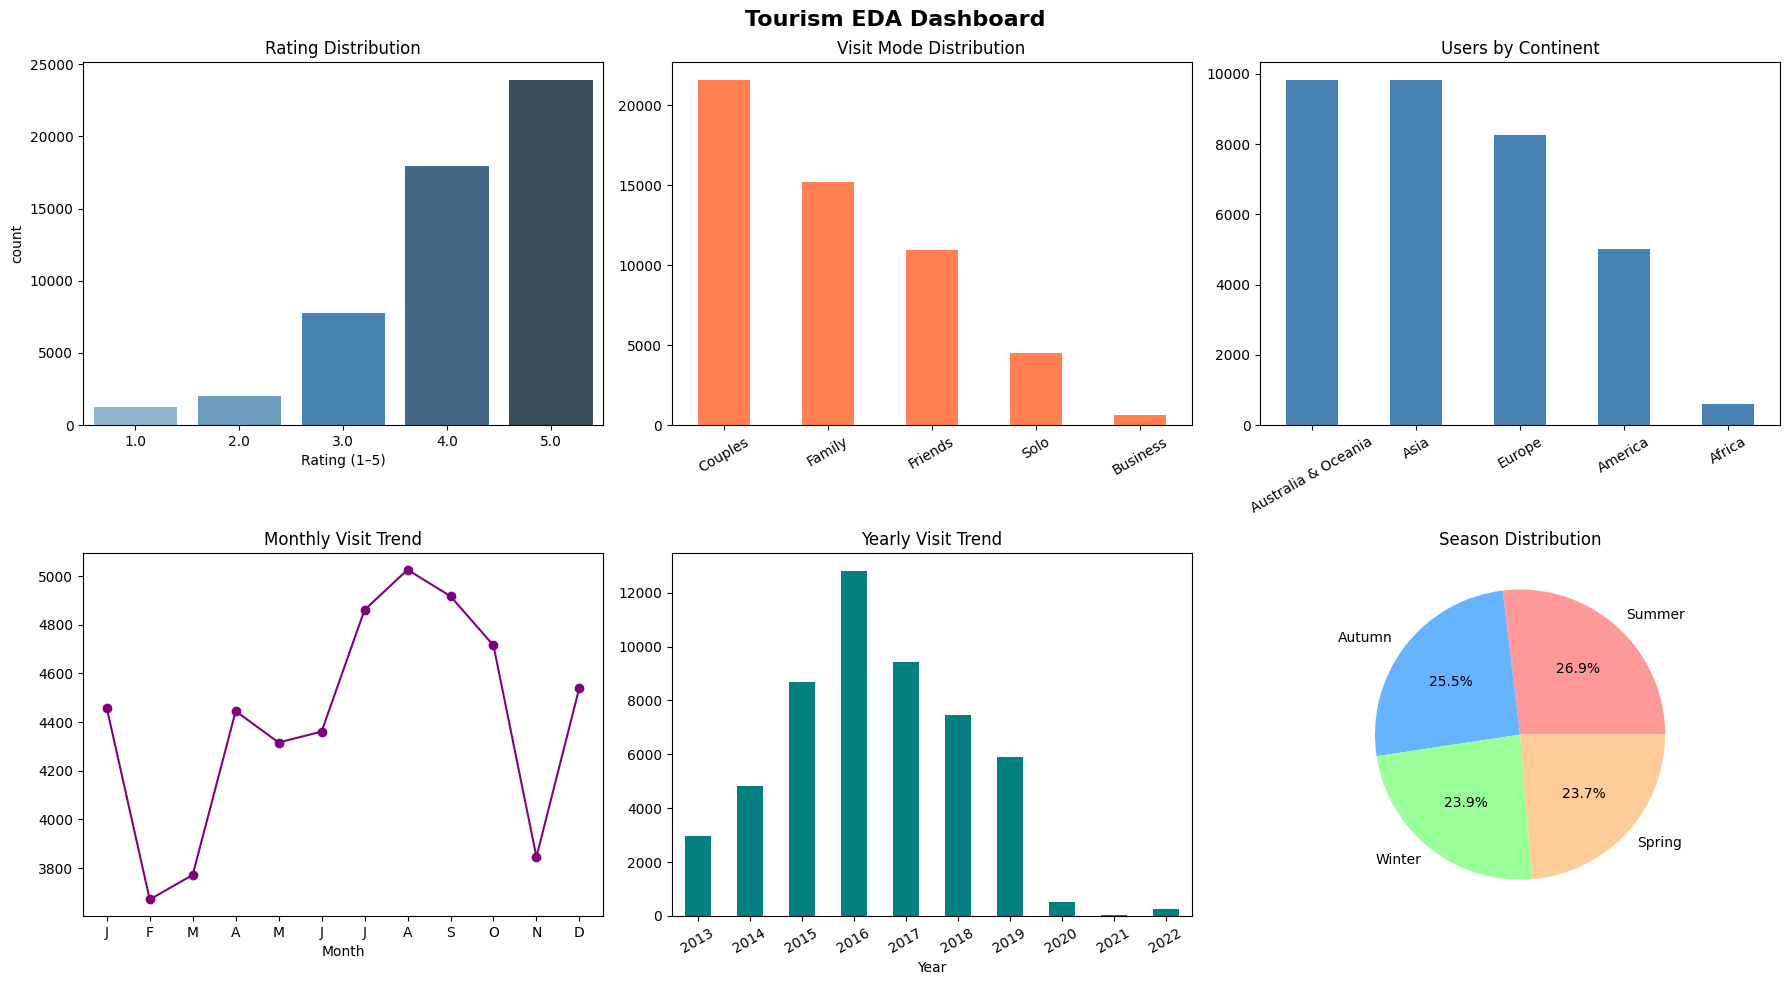

✅ Plot saved as eda_dashboard.png


In [25]:
# CELL 11 — EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Tourism EDA Dashboard", fontsize=16, fontweight="bold")

# 1. Rating Distribution
sns.countplot(x="Rating", data=df, palette="Blues_d", ax=axes[0, 0])
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating (1–5)")

# 2. Visit Mode Distribution
vm_counts = df["VisitModeName"].value_counts()
vm_counts.plot(kind="bar", color="coral", ax=axes[0, 1])
axes[0, 1].set_title("Visit Mode Distribution")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=30)

# 3. Users by Continent
cont_data = df.drop_duplicates("UserId")["Continent"].value_counts()
cont_data.plot(kind="bar", color="steelblue", ax=axes[0, 2])
axes[0, 2].set_title("Users by Continent")
axes[0, 2].set_xlabel("")
axes[0, 2].tick_params(axis="x", rotation=30)

# 4. Monthly Visit Trend
monthly = df.groupby("VisitMonth").size()
monthly.plot(kind="line", marker="o", color="purple", ax=axes[1, 0])
axes[1, 0].set_title("Monthly Visit Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])

# 5. Yearly Visit Trend
yearly = df.groupby("VisitYear").size()
yearly.plot(kind="bar", color="teal", ax=axes[1, 1])
axes[1, 1].set_title("Yearly Visit Trend")
axes[1, 1].set_xlabel("Year")
axes[1, 1].tick_params(axis="x", rotation=30)

# 6. Season Distribution
season_counts = df["Season"].value_counts()
season_counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[1, 2],
                   colors=["#ff9999","#66b3ff","#99ff99","#ffcc99"])
axes[1, 2].set_title("Season Distribution")
axes[1, 2].set_ylabel("")

plt.tight_layout()
plt.savefig("eda_dashboard.png", bbox_inches="tight")
plt.show()
print("✅ Plot saved as eda_dashboard.png")

### 1. Rating Distribution

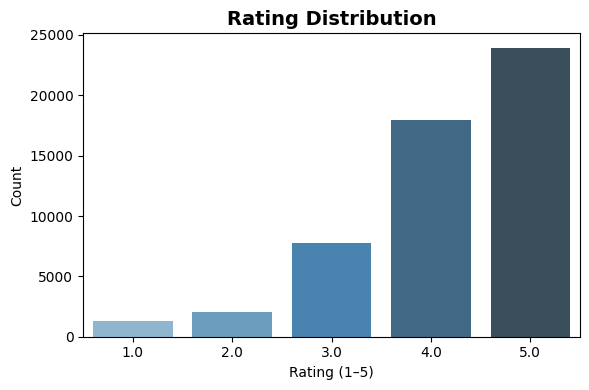

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Rating", data=df, palette="Blues_d")

plt.title("Rating Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Rating (1–5)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 2. Visit Mode Distribution

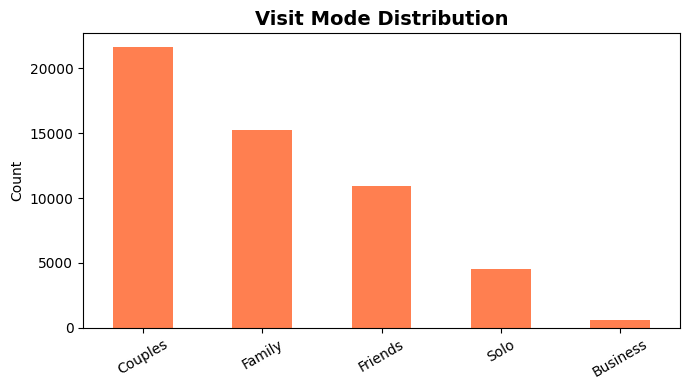

In [27]:
plt.figure(figsize=(7, 4))

vm_counts = df["VisitModeName"].value_counts()

vm_counts.plot(kind="bar", color="coral")

plt.title("Visit Mode Distribution", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 3. Users by Continent

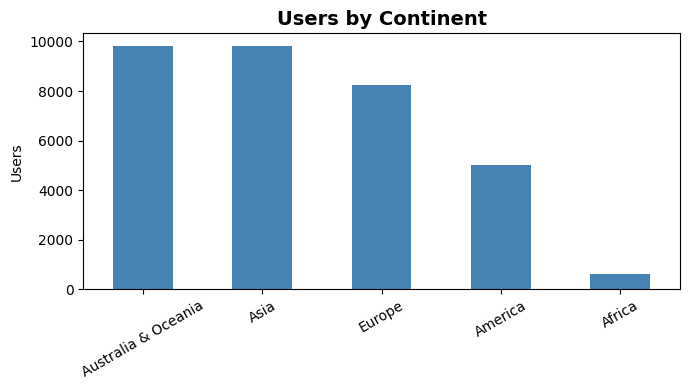

In [28]:
plt.figure(figsize=(7, 4))

cont_data = df.drop_duplicates("UserId")["Continent"].value_counts()

cont_data.plot(kind="bar", color="steelblue")

plt.title("Users by Continent", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Users")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 4. Monthly Visit Trend

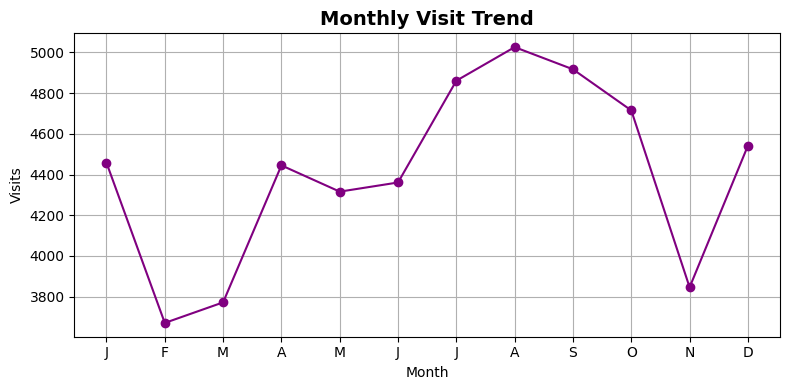

In [29]:
plt.figure(figsize=(8, 4))

monthly = df.groupby("VisitMonth").size()

monthly.plot(kind="line", marker="o", color="purple")

plt.title("Monthly Visit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Visits")

plt.xticks(
    range(1, 13),
    ["J","F","M","A","M","J","J","A","S","O","N","D"]
)

plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Yearly Visit Trend

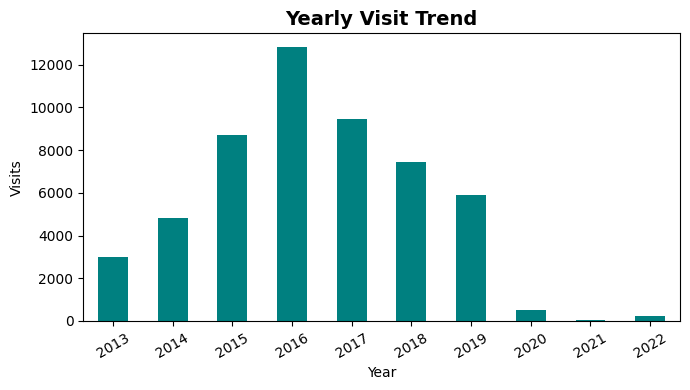

In [30]:
plt.figure(figsize=(7, 4))

yearly = df.groupby("VisitYear").size()

yearly.plot(kind="bar", color="teal")

plt.title("Yearly Visit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Visits")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 6. Season Distribution

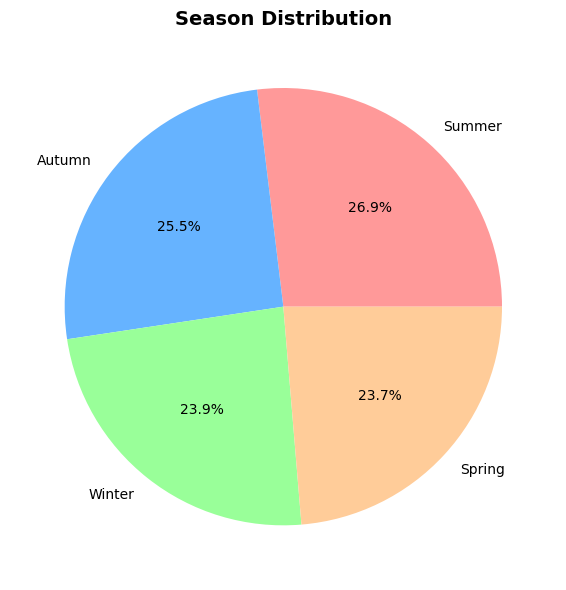

In [31]:
plt.figure(figsize=(6, 6))

season_counts = df["Season"].value_counts()

season_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]
)

plt.title("Season Distribution", fontsize=14, fontweight="bold")
plt.ylabel("")

plt.tight_layout()
plt.show()

### 7. Top 15 Most Visited Attractions

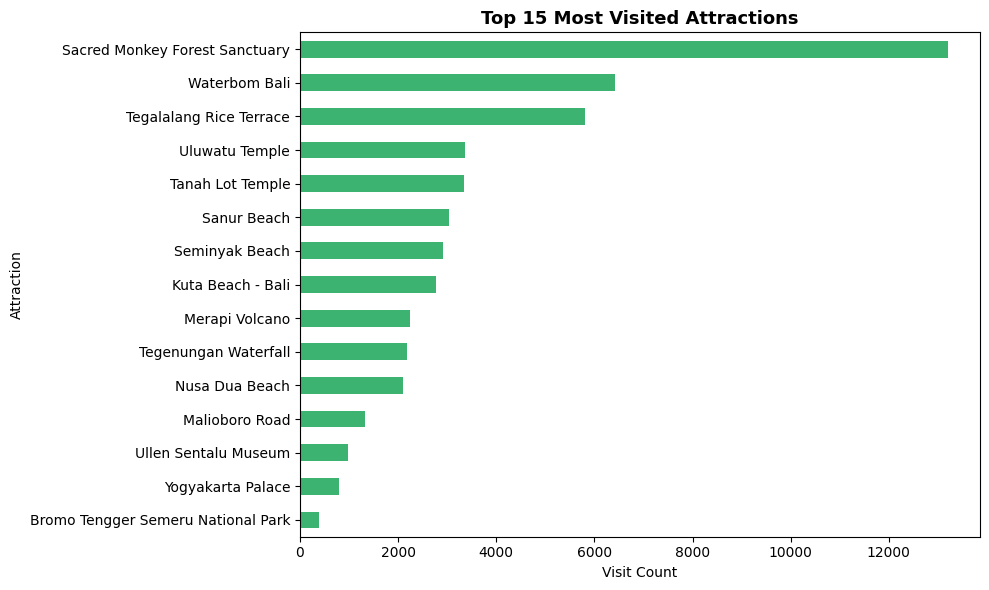

In [32]:
plt.figure(figsize=(10, 6))

top_attr = df["Attraction"].value_counts().head(15)

top_attr.plot(kind="barh", color="mediumseagreen")

plt.title("Top 15 Most Visited Attractions", fontsize=13, fontweight="bold")
plt.xlabel("Visit Count")
plt.ylabel("Attraction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 8. Avg Rating by Attraction Type

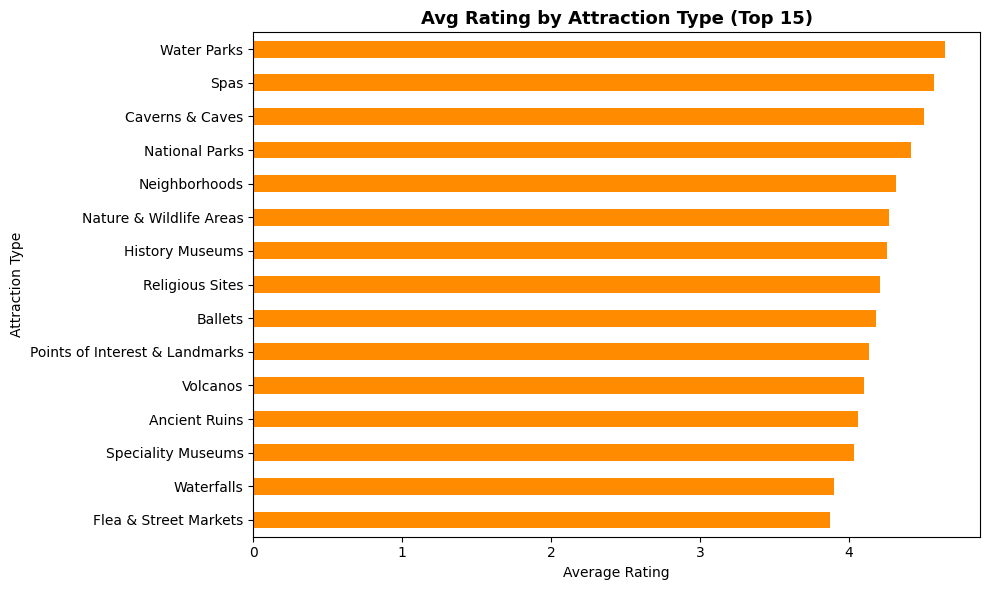

In [33]:
plt.figure(figsize=(10, 6))

avg_by_type = (
    df.groupby("AttractionType")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

avg_by_type.plot(kind="barh", color="darkorange")

plt.title("Avg Rating by Attraction Type (Top 15)", fontsize=13, fontweight="bold")
plt.xlabel("Average Rating")
plt.ylabel("Attraction Type")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 9. Heatmap: Visit Mode vs Continent

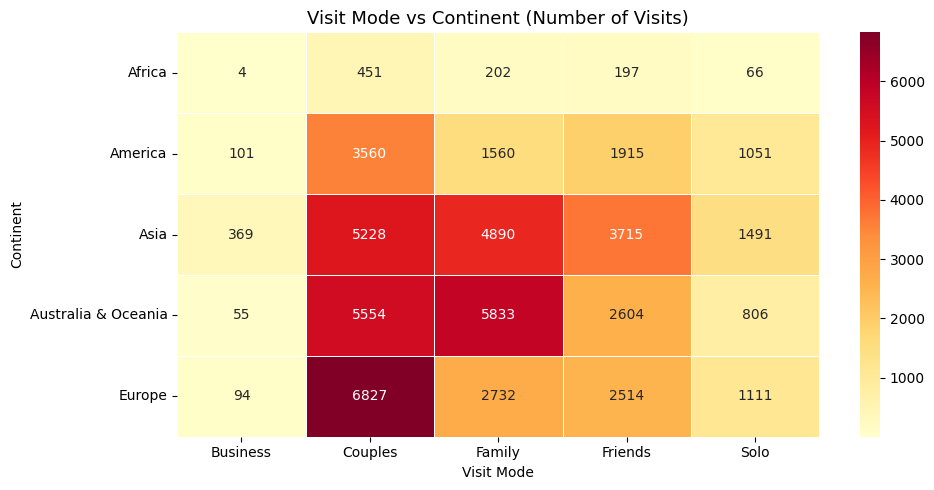

In [34]:
hm_data = df.groupby(["Continent", "VisitModeName"]).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(hm_data, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Visit Mode vs Continent (Number of Visits)", fontsize=13)
plt.xlabel("Visit Mode")
plt.ylabel("Continent")
plt.tight_layout()
plt.show()

### 10.  Correlation Heatmap — Numerical Features

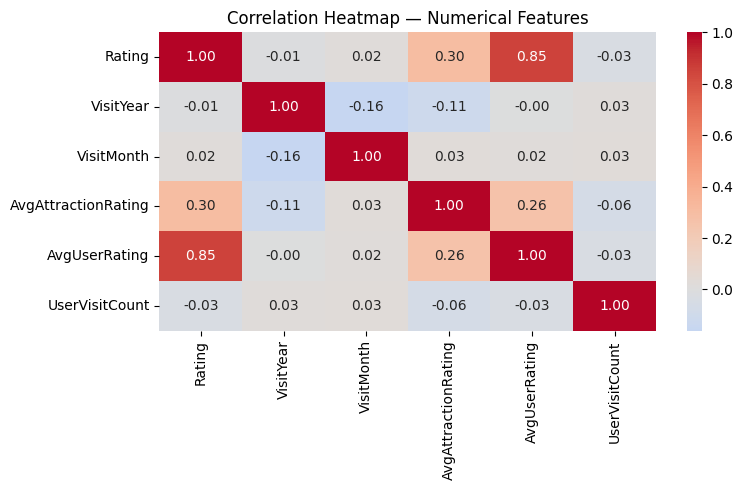

In [35]:
num_cols = ["Rating", "VisitYear", "VisitMonth",
            "AvgAttractionRating", "AvgUserRating", "UserVisitCount"]

plt.figure(figsize=(8, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

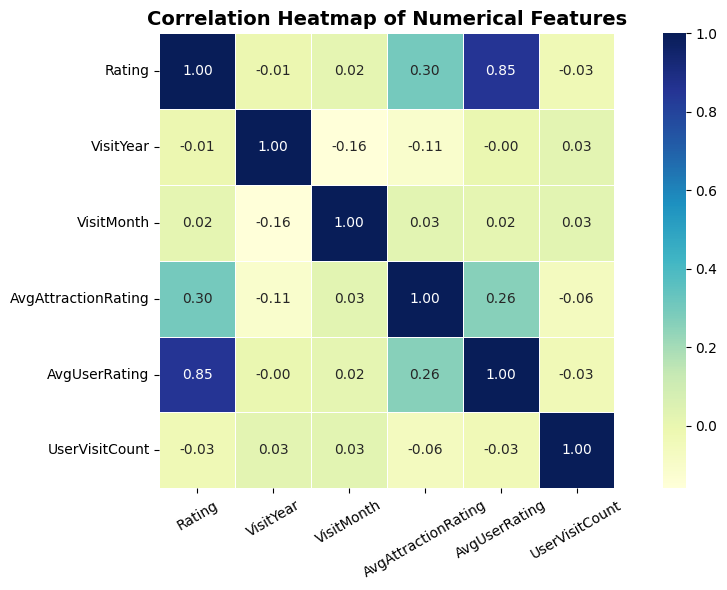

In [36]:
# Select only numerical columns
num_cols = [
    "Rating",
    "VisitYear",
    "VisitMonth",
    "AvgAttractionRating",
    "AvgUserRating",
    "UserVisitCount"
]

# Create correlation matrix
corr_matrix = df[num_cols].corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",          # Different color palette
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size": 10}
)

# Title
plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()

# Save figure
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

# Encode Categorical Features 

In [37]:
# CELL 15 — Label Encoding for ML models
cat_cols = ["Continent", "RegionName", "Country", "CityName",
            "AttractionType", "Season", "VisitModeName"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded: {col:20s} → {col}_enc   (classes: {len(le.classes_)})")

# Save encoders for later use
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("\n Encoders saved to encoders.pkl")

Encoded: Continent            → Continent_enc   (classes: 5)
Encoded: RegionName           → RegionName_enc   (classes: 22)
Encoded: Country              → Country_enc   (classes: 153)
Encoded: CityName             → CityName_enc   (classes: 5546)
Encoded: AttractionType       → AttractionType_enc   (classes: 17)
Encoded: Season               → Season_enc   (classes: 4)
Encoded: VisitModeName        → VisitModeName_enc   (classes: 5)

 Encoders saved to encoders.pkl


# Prepare Feature Matrix 

In [39]:
FEATURES = [
    "ContinentId", "RegionId", "CountryId", "CityId",
    "AttractionTypeId", "VisitYear", "VisitMonth",
    "AvgAttractionRating", "AvgUserRating", "UserVisitCount",
    "Continent_enc", "RegionName_enc", "Country_enc",
    "CityName_enc", "AttractionType_enc", "Season_enc"
]

TARGET_REGRESSION     = "Rating"        # Regression target
TARGET_CLASSIFICATION = "VisitMode"     # Classification target (1–5)

df_model = df[FEATURES + [TARGET_REGRESSION, TARGET_CLASSIFICATION]].dropna()

X             = df_model[FEATURES]
y_rating      = df_model[TARGET_REGRESSION]
y_visit_mode  = df_model[TARGET_CLASSIFICATION]

print(f"Model dataset shape: {df_model.shape}")
print(f"\nFeature matrix X   : {X.shape}")
print(f"Target (Rating)    : {y_rating.shape}  → values: {sorted(y_rating.unique())}")
print(f"Target (VisitMode) : {y_visit_mode.shape} → classes: {sorted(y_visit_mode.unique())}")

# Save features list
with open("features.pkl", "wb") as f:
    pickle.dump(FEATURES, f)
print("\n Feature list saved to features.pkl")

Model dataset shape: (52930, 18)

Feature matrix X   : (52930, 16)
Target (Rating)    : (52930,)  → values: [1.0, 2.0, 3.0, 4.0, 5.0]
Target (VisitMode) : (52930,) → classes: [1, 2, 3, 4, 5]

 Feature list saved to features.pkl


# Regression: Predict Rating

In [40]:
# CELL 17 — REGRESSION: Predict Rating (1–5)
print("=" * 60)
print("REGRESSION — Predicting Attraction Rating")
print("=" * 60)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_rating, test_size=0.2, random_state=42
)

reg_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost"      : XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    preds  = model.predict(X_test_r)
    mse    = mean_squared_error(y_test_r, preds)
    rmse   = np.sqrt(mse)
    r2     = r2_score(y_test_r, preds)
    reg_results[name] = {"MSE": round(mse, 4), "RMSE": round(rmse, 4), "R²": round(r2, 4)}
    print(f"\n{name}")
    print(f"  MSE  = {mse:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")

results_reg_df = pd.DataFrame(reg_results).T
print("\n--- Regression Model Comparison ---")
display(results_reg_df)

REGRESSION — Predicting Attraction Rating

Random Forest
  MSE  = 0.2921
  RMSE = 0.5405
  R²   = 0.6898

XGBoost
  MSE  = 0.2608
  RMSE = 0.5107
  R²   = 0.7231

--- Regression Model Comparison ---


,MSE,RMSE,R²
Random Forest,0.2921,0.5405,0.6898
XGBoost,0.2608,0.5107,0.7231


### Pick best model by R²

In [41]:
best_reg_name  = results_reg_df["R²"].idxmax()
best_reg_model = reg_models[best_reg_name]
print(f"\nBest Regression Model: {best_reg_name}")


Best Regression Model: XGBoost


# Save Best Regression Model 

In [42]:
# CELL 18 — Save the best regression model
with open("regression_model.pkl", "wb") as f:
    pickle.dump(best_reg_model, f)
print(f" Regression model ({best_reg_name}) saved to regression_model.pkl")

 Regression model (XGBoost) saved to regression_model.pkl


# Classification: Predict Visit Mode

In [44]:
# =====================================
# CLASSIFICATION — Predict Visit Mode
# =====================================

print("=" * 60)
print("CLASSIFICATION — Predicting Visit Mode")
print("=" * 60)

# Encode target labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_visit_mode)

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Models
clf_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="mlogloss",
        verbosity=0,
        n_jobs=-1
    )
}

# Training and Evaluation
clf_results = {}

for name, model in clf_models.items():

    # Train model
    model.fit(X_train_c, y_train_c)

    # Predictions
    preds = model.predict(X_test_c)

    # Metrics
    acc = accuracy_score(y_test_c, preds)
    f1  = f1_score(y_test_c, preds, average="weighted")

    clf_results[name] = {
        "Accuracy": round(acc, 4),
        "F1 (weighted)": round(f1, 4)
    }

    print(f"\n{name}")
    print(f"Accuracy      = {acc:.4f}")
    print(f"F1 (weighted) = {f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test_c,
            preds,
            target_names=le.classes_.astype(str)
        )
    )

# Comparison Table
results_clf_df = pd.DataFrame(clf_results).T

print("\n--- Classification Model Comparison ---")

display(results_clf_df)

CLASSIFICATION — Predicting Visit Mode

Random Forest
Accuracy      = 0.5363
F1 (weighted) = 0.5217

Classification Report:

              precision    recall  f1-score   support

           1       0.53      0.25      0.34       125
           2       0.55      0.71      0.62      4324
           3       0.55      0.53      0.54      3043
           4       0.46      0.33      0.39      2189
           5       0.53      0.25      0.34       905

    accuracy                           0.54     10586
   macro avg       0.53      0.41      0.44     10586
weighted avg       0.53      0.54      0.52     10586


XGBoost
Accuracy      = 0.5217
F1 (weighted) = 0.4840

Classification Report:

              precision    recall  f1-score   support

           1       0.67      0.14      0.24       125
           2       0.52      0.80      0.63      4324
           3       0.55      0.48      0.51      3043
           4       0.46      0.23      0.31      2189
           5       0.67      0.10  

,Accuracy,F1 (weighted)
Random Forest,0.5363,0.5217
XGBoost,0.5217,0.4840


### Pick the best model 

In [45]:
best_clf_name  = results_clf_df["F1 (weighted)"].idxmax()
best_clf_model = clf_models[best_clf_name]
print(f"\nBest Classification Model: {best_clf_name}")


Best Classification Model: Random Forest


# Save Best Classification Model

In [46]:
# CELL 20 — Save best classification model
with open("classification_model.pkl", "wb") as f:
    pickle.dump(best_clf_model, f)
print(f"Classification model ({best_clf_name}) saved to classification_model.pkl")

Classification model (Random Forest) saved to classification_model.pkl


# Feature Importance Plots for Best Models 

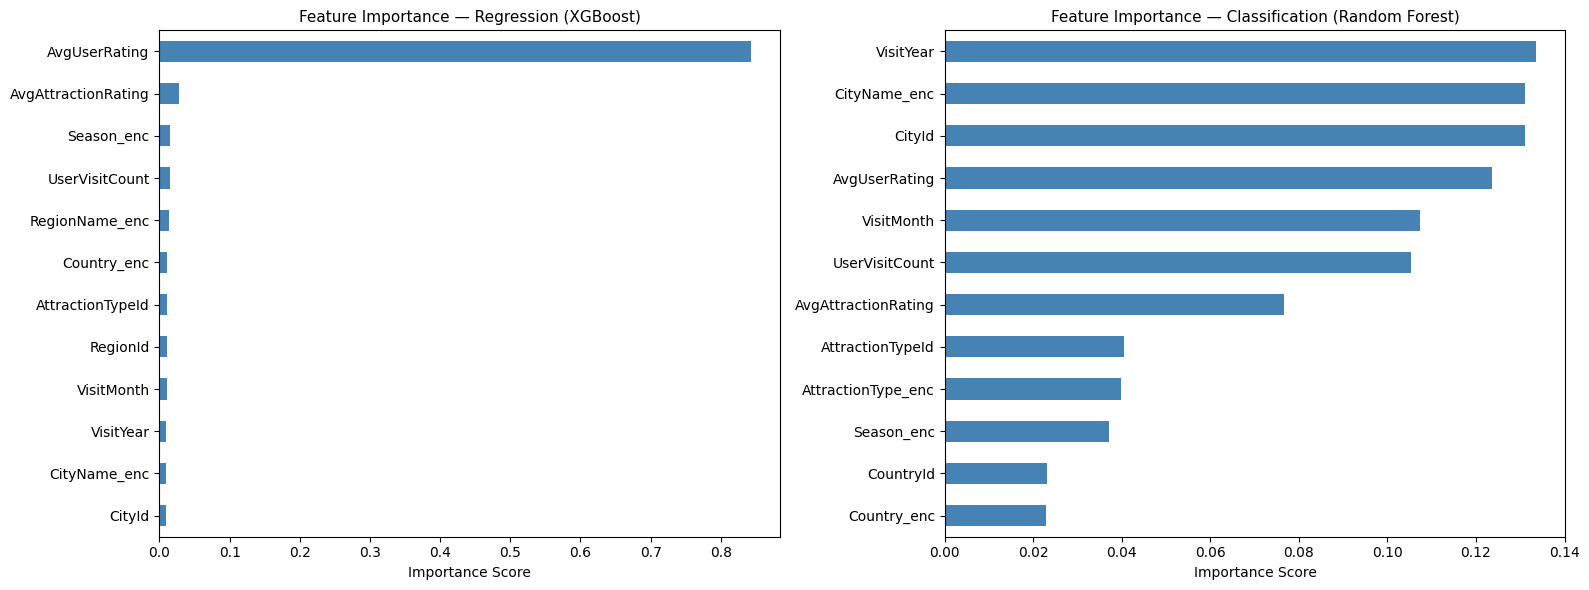

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in [
    (axes[0], best_reg_model, f"Feature Importance — Regression ({best_reg_name})"),
    (axes[1], best_clf_model, f"Feature Importance — Classification ({best_clf_name})")
]:
    importances = pd.Series(model.feature_importances_, index=FEATURES)
    importances.sort_values(ascending=True).tail(12).plot(
        kind="barh", ax=ax, color="steelblue"
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

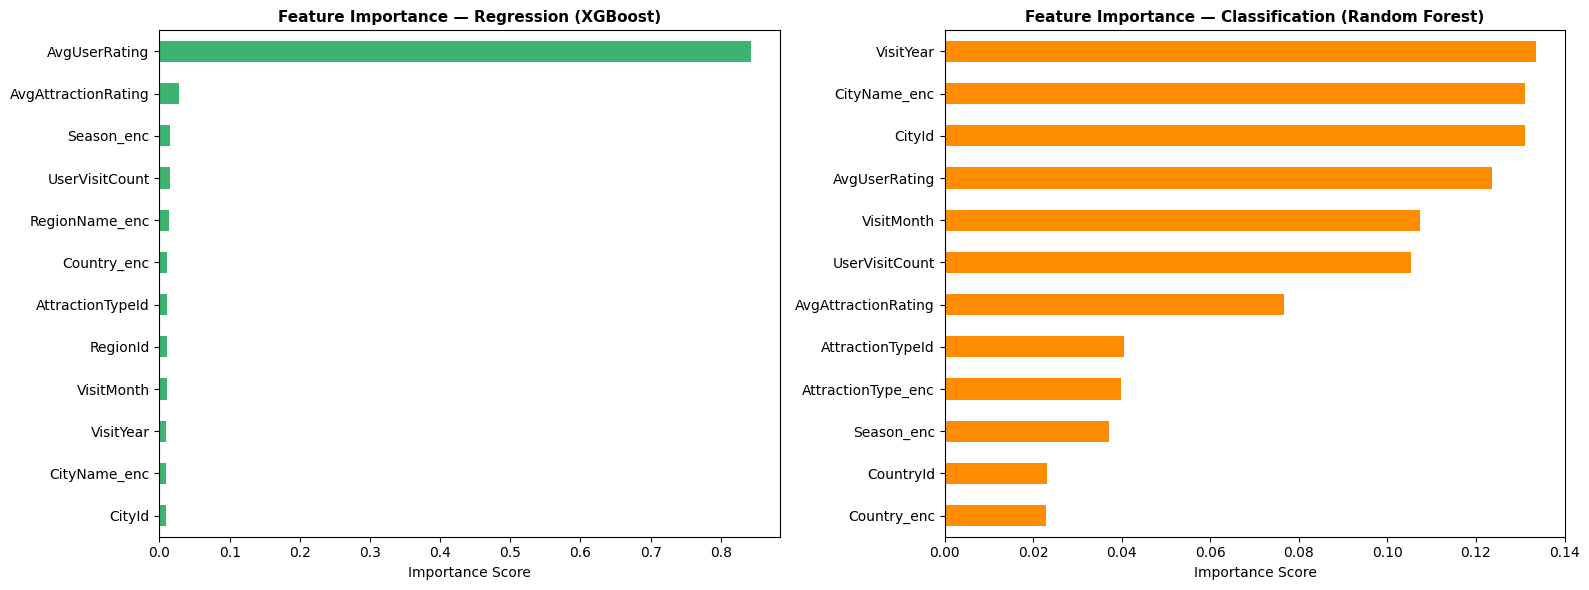

In [48]:
# =====================================
# Feature Importance Plots
# =====================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------
# Regression Feature Importance
# -------------------------------------
reg_importances = pd.Series(
    best_reg_model.feature_importances_,
    index=FEATURES
)

reg_importances.sort_values(ascending=True).tail(12).plot(
    kind="barh",
    ax=axes[0],
    color="mediumseagreen"     # Green color
)

axes[0].set_title(
    f"Feature Importance — Regression ({best_reg_name})",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_xlabel("Importance Score")


# -------------------------------------
# Classification Feature Importance
# -------------------------------------
clf_importances = pd.Series(
    best_clf_model.feature_importances_,
    index=FEATURES
)

clf_importances.sort_values(ascending=True).tail(12).plot(
    kind="barh",
    ax=axes[1],
    color="darkorange"         # Orange color
)

axes[1].set_title(
    f"Feature Importance — Classification ({best_clf_name})",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_xlabel("Importance Score")


# -------------------------------------
# Layout
# -------------------------------------
plt.tight_layout()
plt.show()

# Recommendation System: Collaborative Filtering

In [49]:
# CELL 22 — COLLABORATIVE FILTERING Recommendation System

def collaborative_recommend(user_id, df, top_n=10):
    """
    Recommend attractions for a given user based on 
    similar users' ratings (user-item cosine similarity).
    """
    # Build User-Item matrix
    matrix = df.pivot_table(
        index="UserId",
        columns="AttractionId",
        values="Rating",
        aggfunc="mean"
    ).fillna(0)

    if user_id not in matrix.index:
        print(f"UserId {user_id} not found → returning global top attractions")
        return global_top_attractions(df, top_n)

    # Compute cosine similarity between users
    sim_matrix = cosine_similarity(matrix)
    sim_df     = pd.DataFrame(sim_matrix, index=matrix.index, columns=matrix.index)

    # Top 20 similar users
    similar_users = sim_df[user_id].drop(user_id).sort_values(ascending=False).head(20).index

    # Attractions already visited by the target user
    visited = set(df[df["UserId"] == user_id]["AttractionId"])

    # Weighted scores for unvisited attractions
    scores = {}
    for su in similar_users:
        weight = sim_df[user_id][su]
        rated  = df[df["UserId"] == su][["AttractionId", "Rating"]]
        for _, row in rated.iterrows():
            aid = row["AttractionId"]
            if aid not in visited:
                scores[aid] = scores.get(aid, 0) + weight * row["Rating"]

    if not scores:
        print("Not enough data → returning global top attractions")
        return global_top_attractions(df, top_n)

    # Rank by score
    top_ids = sorted(scores, key=scores.get, reverse=True)[:top_n]
    result  = (df[df["AttractionId"].isin(top_ids)]
               [["AttractionId", "Attraction", "AttractionType", "AvgAttractionRating"]]
               .drop_duplicates("AttractionId")
               .reset_index(drop=True))
    return result


def content_based_recommend(attraction_id, df, top_n=10):
    """
    Recommend attractions similar to a given AttractionId
    based on AttractionTypeId and AttractionCityId.
    """
    item_df = df[["AttractionId", "AttractionTypeId", "AttractionCityId",
                  "AvgAttractionRating"]].drop_duplicates("AttractionId")

    if attraction_id not in item_df["AttractionId"].values:
        print(f"AttractionId {attraction_id} not found.")
        return pd.DataFrame()

    type_d = pd.get_dummies(item_df["AttractionTypeId"], prefix="type")
    city_d = pd.get_dummies(item_df["AttractionCityId"], prefix="city")
    feat   = pd.concat([type_d, city_d], axis=1)
    feat.index = item_df["AttractionId"].values

    sim    = cosine_similarity(feat)
    sim_df = pd.DataFrame(sim, index=feat.index, columns=feat.index)

    similar_ids = (sim_df[attraction_id]
                   .drop(attraction_id)
                   .sort_values(ascending=False)
                   .head(top_n)
                   .index.tolist())

    result = (df[df["AttractionId"].isin(similar_ids)]
              [["AttractionId", "Attraction", "AttractionType", "AvgAttractionRating"]]
              .drop_duplicates("AttractionId")
              .reset_index(drop=True))
    return result


def global_top_attractions(df, top_n=10):
    """Return top N attractions by average rating and visit count."""
    return (df.groupby(["AttractionId", "Attraction", "AttractionType"])
              .agg(AvgRating=("Rating", "mean"), TotalVisits=("Rating", "count"))
              .reset_index()
              .sort_values(["AvgRating", "TotalVisits"], ascending=False)
              .head(top_n)
              .reset_index(drop=True))


print(" Recommendation functions defined!")

 Recommendation functions defined!


# Test Recommendations

### Collaborative Filtering

In [50]:
sample_user = df["UserId"].value_counts().index[0]   # most active user
print(f"\n Collaborative Filtering — Recommendations for UserId={sample_user}")
recs_collab = collaborative_recommend(sample_user, df, top_n=10)
display(recs_collab)


 Collaborative Filtering — Recommendations for UserId=60799


,AttractionId,Attraction,AttractionType,AvgAttractionRating
0,841,Waterbom Bali,Water Parks,4.646601
1,824,Uluwatu Temple,Religious Sites,4.219411
2,749,Tegenungan Waterfall,Waterfalls,3.895434
3,737,Tanah Lot Temple,Religious Sites,4.194809
4,1166,Malioboro Road,Flea & Street Markets,3.869335


### Content-Based Filtering

In [51]:
sample_attr = df["AttractionId"].value_counts().index[0]
sample_name = df[df["AttractionId"] == sample_attr]["Attraction"].iloc[0]
print(f"\n Content-Based Filtering — Attractions similar to '{sample_name}' (ID={sample_attr})")
recs_content = content_based_recommend(sample_attr, df, top_n=10)
display(recs_content)


 Content-Based Filtering — Attractions similar to 'Sacred Monkey Forest Sanctuary' (ID=640)


,AttractionId,Attraction,AttractionType,AvgAttractionRating
0,841,Waterbom Bali,Water Parks,4.646601
1,673,Seminyak Beach,Beaches,3.800618
2,481,Nusa Dua Beach,Beaches,4.275665
3,650,Sanur Beach,Beaches,3.976347
4,824,Uluwatu Temple,Religious Sites,4.219411
5,748,Tegalalang Rice Terrace,Points of Interest & Landmarks,4.157524
6,749,Tegenungan Waterfall,Waterfalls,3.895434
7,737,Tanah Lot Temple,Religious Sites,4.194809
8,369,Kuta Beach - Bali,Beaches,3.415190
9,975,Sempu Island,Nature & Wildlife Areas,4.207547


### Global Top

In [52]:
print("\n Global Top 10 Attractions (by Avg Rating + Visits)")
display(global_top_attractions(df, top_n=10))


 Global Top 10 Attractions (by Avg Rating + Visits)


,AttractionId,Attraction,AttractionType,AvgRating,TotalVisits
0,947,Mount Semeru Volcano,Volcanos,4.698795,83
1,841,Waterbom Bali,Water Parks,4.646601,6429
2,888,Bromo Tengger Semeru National Park,National Parks,4.611549,381
3,928,Khayangan Reflexology & Massage,Spas,4.571429,28
4,1133,Jomblang Cave,Caverns & Caves,4.503704,135
5,920,Jodipan Colorful Village,Neighborhoods,4.318182,44
6,481,Nusa Dua Beach,Beaches,4.275665,2104
7,640,Sacred Monkey Forest Sanctuary,Nature & Wildlife Areas,4.267086,13198
8,1278,Ullen Sentalu Museum,History Museums,4.256646,978
9,824,Uluwatu Temple,Religious Sites,4.219411,3359


# Test Regression Prediction

In [54]:
#  Test: Predict Rating for a sample input
VISIT_MODE_MAP = {1: "Business", 2: "Couples", 3: "Family", 4: "Friends", 5: "Solo"}

# Take first row from test set as example
sample_row = X_test_r.iloc[[0]]
actual_rating = y_test_r.iloc[0]
predicted_rating = np.clip(best_reg_model.predict(sample_row)[0], 1.0, 5.0)

print("REGRESSION PREDICTION TEST")
print(f"Actual Rating   : {actual_rating}")
print(f"Predicted Rating: {predicted_rating:.2f}")

REGRESSION PREDICTION TEST
Actual Rating   : 5.0
Predicted Rating: 4.33


# Test Classification Prediction

In [56]:
# =====================================
# Test: Predict Visit Mode for Sample Input
# =====================================

sample_row2 = X_test_c.iloc[[0]]

# Actual value
actual_mode = y_test_c[0]

# Prediction
predicted_mode_id = best_clf_model.predict(sample_row2)[0]

# Convert IDs to names
predicted_mode_name = VISIT_MODE_MAP.get(
    int(predicted_mode_id),
    "Unknown"
)

actual_mode_name = VISIT_MODE_MAP.get(
    int(actual_mode),
    "Unknown"
)

# Print results
print("=" * 50)
print("CLASSIFICATION PREDICTION TEST")
print("=" * 50)

print(f"Actual Visit Mode    : {actual_mode_name} ({actual_mode})")
print(f"Predicted Visit Mode : {predicted_mode_name} ({predicted_mode_id})")


# =====================================
# Prediction Probabilities
# =====================================

if hasattr(best_clf_model, "predict_proba"):

    probs = best_clf_model.predict_proba(sample_row2)[0]

    classes = best_clf_model.classes_

    prob_df = pd.DataFrame({
        "Visit Mode": [
            VISIT_MODE_MAP.get(int(c), str(c))
            for c in classes
        ],
        "Probability": probs
    })

    prob_df = prob_df.sort_values(
        "Probability",
        ascending=False
    )

    print("\nPrediction Probabilities:\n")

    display(prob_df)

CLASSIFICATION PREDICTION TEST
Actual Visit Mode    : Family (3)
Predicted Visit Mode : Couples (2)

Prediction Probabilities:



,Visit Mode,Probability
2,Couples,0.725277
1,Business,0.144723
4,Friends,0.080000
3,Family,0.050000
0,0,0.000000


# Save MAster Dataset

In [57]:
# CELL 26 — Save master dataset to CSV
df.to_csv("master_dataset.csv", index=False)
print(f" Master dataset saved → master_dataset.csv")
print(f"   Shape: {df.shape}")
print(f"\nFiles saved in this project:")
import os
for fname in ["master_dataset.csv", "encoders.pkl",
              "features.pkl", "regression_model.pkl", "classification_model.pkl"]:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    status = "" if os.path.exists(fname) else ""
    print(f"  {status} {fname:35s} ({size:,} bytes)")

 Master dataset saved → master_dataset.csv
   Shape: (52930, 31)

Files saved in this project:
   master_dataset.csv                  (10,063,048 bytes)
   encoders.pkl                        (72,101 bytes)
   features.pkl                        (257 bytes)
   regression_model.pkl                (448,891 bytes)
   classification_model.pkl            (334,100,581 bytes)


# Final Summary Report

In [58]:
# CELL 27 — Final Summary
print("=" * 60)
print("   TOURISM ANALYTICS PROJECT — FINAL SUMMARY")
print("=" * 60)

print(f"\nDATA")
print(f"  Total records     : {len(df):,}")
print(f"  Unique users      : {df['UserId'].nunique():,}")
print(f"  Unique attractions: {df['AttractionId'].nunique():,}")
print(f"  Year range        : {df['VisitYear'].min()} – {df['VisitYear'].max()}")
print(f"  Average rating    : {df['Rating'].mean():.2f}")

print(f"\nREGRESSION — Predict Rating")
display(results_reg_df)

print(f"\nCLASSIFICATION — Predict Visit Mode")
display(results_clf_df)

print(f"\n RECOMMENDATIONS")
print(f"   Collaborative Filtering — user-item cosine similarity")
print(f"   Content-Based Filtering — attraction features similarity")
print(f"   Global Top Attractions  — by avg rating + visit count")

print("\n OUTPUT FILES")
for fname in ["master_dataset.csv", "encoders.pkl",
              "features.pkl", "regression_model.pkl", "classification_model.pkl"]:
    print(f"  → {fname}")

print("\n NEXT STEP: Run app.py with Streamlit!")

   TOURISM ANALYTICS PROJECT — FINAL SUMMARY

DATA
  Total records     : 52,930
  Unique users      : 33,530
  Unique attractions: 30
  Year range        : 2013 – 2022
  Average rating    : 4.16

REGRESSION — Predict Rating


,MSE,RMSE,R²
Random Forest,0.2921,0.5405,0.6898
XGBoost,0.2608,0.5107,0.7231



CLASSIFICATION — Predict Visit Mode


,Accuracy,F1 (weighted)
Random Forest,0.5363,0.5217
XGBoost,0.5217,0.4840



 RECOMMENDATIONS
   Collaborative Filtering — user-item cosine similarity
   Content-Based Filtering — attraction features similarity
   Global Top Attractions  — by avg rating + visit count

 OUTPUT FILES
  → master_dataset.csv
  → encoders.pkl
  → features.pkl
  → regression_model.pkl
  → classification_model.pkl

 NEXT STEP: Run app.py with Streamlit!
